In [2]:
# Cellule 1 : Imports et configuration
%load_ext autoreload
%autoreload 2

import tools.ai_token as tk
import tools.ai_attention_decoder as att
import os
import random


In [12]:
# Configuration
base_folder = "data/train/wiki_fr_test"
output_file = "data/corpus_tokenizer_15mb.txt"
num_files_to_merge = 15

# 1. Récupérer tous les fichiers de tous les répertoires
all_files = []

# Parcourir tous les répertoires (AA à CN)
for subdir in os.listdir(base_folder):
    subdir_path = os.path.join(base_folder, subdir)
    
    # Vérifier que c'est bien un répertoire
    if os.path.isdir(subdir_path):
        # Récupérer tous les fichiers .txt du répertoire
        files_in_subdir = [f for f in os.listdir(subdir_path)]
        
        # Ajouter le chemin complet à la liste
        for fname in files_in_subdir:
            full_path = os.path.join(subdir_path, fname)
            all_files.append(full_path)

print(f"Total fichiers trouvés : {len(all_files)}")

# 2. Sélection aléatoire
if len(all_files) > num_files_to_merge:
    selected_files = random.sample(all_files, num_files_to_merge)
else:
    selected_files = all_files
    print(f"Attention : Seulement {len(selected_files)} fichiers disponibles")

print(f"Fusion de {len(selected_files)} fichiers...")

# 3. Fusion
total_size = 0
with open(output_file, 'w', encoding='utf-8') as outfile:
    for file_path in selected_files:
        try:
            with open(file_path, 'r', encoding='utf-8') as infile:
                content = infile.read()
                outfile.write(content + "\n")
                total_size += len(content.encode('utf-8'))
                print(f"✓ Ajouté : {file_path}")
        except Exception as e:
            print(f"✗ Erreur avec {file_path} : {e}")

print(f"\nFichier créé : {output_file}")
print(f"Taille approximative : {total_size / (1024*1024):.2f} MB")

Total fichiers trouvés : 6518
Fusion de 15 fichiers...
✓ Ajouté : data/train/wiki_fr_test/BR/wiki_32
✓ Ajouté : data/train/wiki_fr_test/BP/wiki_68
✓ Ajouté : data/train/wiki_fr_test/AA/wiki_16
✓ Ajouté : data/train/wiki_fr_test/BR/wiki_66
✓ Ajouté : data/train/wiki_fr_test/AN/wiki_38
✓ Ajouté : data/train/wiki_fr_test/AW/wiki_29
✓ Ajouté : data/train/wiki_fr_test/BA/wiki_44
✓ Ajouté : data/train/wiki_fr_test/BV/wiki_32
✓ Ajouté : data/train/wiki_fr_test/BM/wiki_82
✓ Ajouté : data/train/wiki_fr_test/AG/wiki_39
✓ Ajouté : data/train/wiki_fr_test/AH/wiki_64
✓ Ajouté : data/train/wiki_fr_test/BO/wiki_17
✓ Ajouté : data/train/wiki_fr_test/BS/wiki_57
✓ Ajouté : data/train/wiki_fr_test/BT/wiki_11
✓ Ajouté : data/train/wiki_fr_test/AY/wiki_89

Fichier créé : data/corpus_tokenizer_15mb.txt
Taille approximative : 14.88 MB


In [13]:
fileName = 'data/corpus_tokenizer_15mb.txt'
token_ = tk.BPETokenizer(fileName=fileName)
print(token_.token[:100])

Nettoyage terminé:
[[100, 111, 99], [32, 105, 100], [34], [56, 55, 50], [56, 51, 57], [52], [34], [32, 117, 114, 108], [34, 104, 116, 116, 112, 115], [58, 102, 114], [46, 119, 105, 107, 105, 112, 101, 100, 105, 97], [46, 111, 114, 103, 119, 105, 107, 105], [63, 99, 117, 114, 105, 100], [56, 55, 50], [56, 51, 57], [52], [34], [32, 116, 105, 116, 108, 101], [34, 84, 114, 97, 100, 105, 116, 105, 111, 110], [32, 100, 117], [32, 99, 104, 97, 110, 116], [32, 103, 114, 195, 169, 103, 111, 114, 105, 101, 110], [32, 97, 117, 112, 114, 195, 168, 115], [32, 100, 101, 115], [32, 109, 111, 110, 97, 115, 116, 195, 168, 114, 101, 115], [34, 10], [84, 114, 97, 100, 105, 116, 105, 111, 110], [32, 100, 117], [32, 99, 104, 97, 110, 116], [32, 103, 114, 195, 169, 103, 111, 114, 105, 101, 110], [32, 97, 117, 112, 114, 195, 168, 115], [32, 100, 101, 115], [32, 109, 111, 110, 97, 115, 116, 195, 168, 114, 101, 115], [10, 10], [83, 105], [32, 108, 101], [32, 99, 104, 97, 110, 116], [32, 103, 114, 195, 169, 103

In [14]:
token_.addToken = 30000
token_.train(False)
print(token_.ids[:100])

[357, 422, 34, 1860, 24095, 52, 34, 449, 445, 446, 450, 444, 451, 1860, 24095, 52, 34, 448, 29414, 1056, 310, 3707, 9098, 2989, 303, 11422, 435, 5041, 1056, 310, 3707, 9098, 2989, 303, 11422, 417, 5713, 286, 3707, 9098, 1163, 547, 3319, 372, 279, 827, 1001, 351, 286, 6592, 262, 15551, 292, 279, 628, 310, 44, 570, 5446, 5196, 2029, 287, 12777, 22621, 2285, 28828, 3618, 467, 2989, 303, 11422, 310, 4006, 23098, 1686, 286, 4035, 2650, 44, 322, 1142, 262, 279, 8262, 23992, 46, 5990, 716, 44, 315, 22279, 256, 21920, 19548, 315, 3404, 15840, 287, 531, 11886]


In [16]:
prompt = "ceci est un essai d'encodage pour voir si tout fonctionne !"
ids = token_.encode(prompt)
print(ids[:100])
print(token_.ids[:100])
print(token_.display_token())
print(token_.display_token(token_.ids[:100]))
print(len(token_.vocab))

[326, 371, 318, 301, 8630, 256, 717, 24419, 480, 372, 3692, 1494, 872, 16559, 32, 33]
[357, 422, 34, 1860, 24095, 52, 34, 449, 445, 446, 450, 444, 451, 1860, 24095, 52, 34, 448, 29414, 1056, 310, 3707, 9098, 2989, 303, 11422, 435, 5041, 1056, 310, 3707, 9098, 2989, 303, 11422, 417, 5713, 286, 3707, 9098, 1163, 547, 3319, 372, 279, 827, 1001, 351, 286, 6592, 262, 15551, 292, 279, 628, 310, 44, 570, 5446, 5196, 2029, 287, 12777, 22621, 2285, 28828, 3618, 467, 2989, 303, 11422, 310, 4006, 23098, 1686, 286, 4035, 2650, 44, 322, 1142, 262, 279, 8262, 23992, 46, 5990, 716, 44, 315, 22279, 256, 21920, 19548, 315, 3404, 15840, 287, 531, 11886]



✓ 16 tokens affichés avec couleurs aléatoires
None



✓ 100 tokens affichés avec couleurs aléatoires
None
30256


In [15]:
token_.save_vocab('data/ep_vocab_full.json')
token_.save_merges('data/ep_merges_full.json')

Vocabulaire sauvegardé dans data/ep_vocab_full.json


# Entrainement du model

In [36]:
token_.display_token(token_.ids)


✓ 500 tokens affichés avec couleurs aléatoires


# Verif

In [ ]:
print(token.ids[:100])

In [ ]:
print(ids1[:100])

In [ ]:
a = token.decode(token.get_array(ids2))
b = token.decode(ids3)
c = token.decode(ids1.tolist())

In [ ]:
print(a[:100])
print(a==b)
print(a==token.text_cleaned)
print(b==token.text_cleaned)

In [ ]:
token.addToken = 400
token.train(verbose=False)

In [ ]:
token.save_merges('data/merges.json')

In [ ]:
print(token._get_max_stats())
print(token._get_max_stats_numpy())

In [ ]:
e = token.encode_np(token.text_cleaned)

In [ ]:
c = (ids[ids != -1]).tolist()

In [ ]:
print(e[-100:])
print(c[-100:])
print(len(c), len(e))
print(c==e)

In [ ]:
print(token.merges)

In [ ]:
token._vocab()

In [ ]:
print(e[:100])
token.display_token(e[:1000])

In [ ]:
text_encode_array = token.get_array(token.ids)
text = token.decode()
print(token.ids[:100])
print(text_encode_array[:100])
print(text[:100])


In [ ]:
print(token.ids[100:200])  # Affiche les 5 premiers échantillons tokenisés
print(token.token[100:200])  # Affiche les 5 premiers échantillons tokenisés en bytes
print(token.vocab)

# Load un vocab

In [ ]:
token.load_vocab(filepath='data/tokenizer.json')

In [ ]:
ids = token.encode_np(token.text_cleaned)

In [ ]:
token.display_token()

# Test decoder

In [37]:
import tools.ai_attention_decoder as at

### Historiques
 * v0 : 60,28s
 * v1 (head et multihead fusionnées) : 29,51s
 * v2 (block et feedforward optimisés et utiliosation de GELU vs ReLU) : 28,40s

In [18]:
config = { 'n_embd': 128,
            'num_heads': 4,
            'n_layers': 4,
            'block_size': 128,
            'dropout': 0.1,      
        }
parameters = {
    'batch_size': 32,
    'max_iters': 2000,
    'eval_interval': 500,
    'eval_iters': 200,
    'learning_rate': 1e-4
}

In [20]:
decoder = att.Model(token_.ids, token_, **config, **parameters, fileout='data/test_train_1.pth')
decoder.get_model_size()

Using device: mps
------------------------------
📊 Model Statistics:
   Total Parameters: 8,583,984
   Trainable:        8,583,984
   Estimated Size:   32.75 MB
------------------------------


🚀 Starting training on mps...
Step 0/2000: train loss 10.4727, val loss 10.4753
Step 500/2000: train loss 7.3878, val loss 7.4343 | ETA: 737.7s
Step 1000/2000: train loss 6.8511, val loss 6.9074 | ETA: 443.8s
Step 1500/2000: train loss 6.5040, val loss 6.5723 | ETA: 213.6s
Step 1999/2000: train loss 6.2967, val loss 6.3852 | ETA: 0.4s

✅ Training completed in 832.41s
----- Saving model -----
Model saved to data/test_train_1.pth


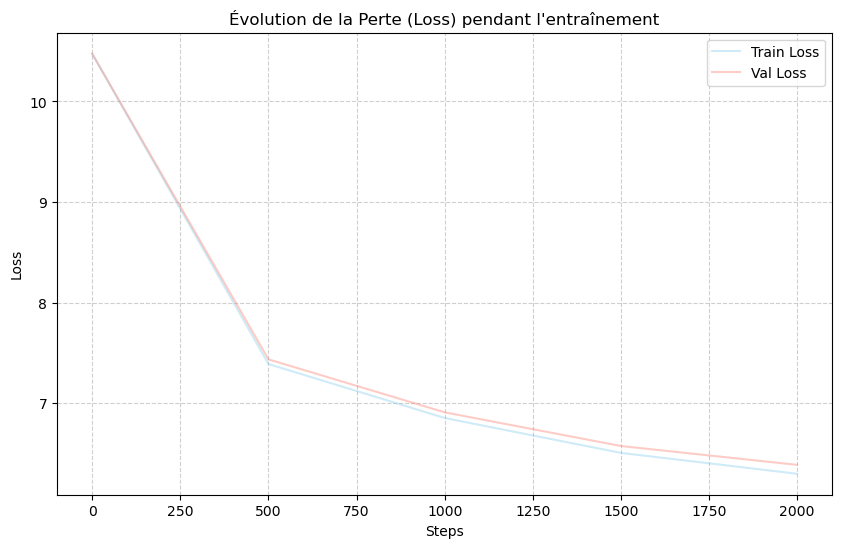

In [21]:
decoder.train()
decoder.plot_losses()


In [22]:
prompt = "Ceci est l'histoire d'un ROI, grand et beau qui raconte sa dernière bataille"
ids_p = token_.encode(prompt)
print(ids_p)

[2125, 371, 318, 259, 1963, 256, 462, 402, 79, 73, 44, 912, 287, 1968, 392, 8959, 492, 2198, 2469]


In [24]:
decoder.genere(new_token=200)

 ad.
Géographie étaient trouvaitlan voisine, l'occasion des109'ohang dans des propositions. z de magie, la taillerimer des),es sur le Galicie, et d'Orléans de Mazovie aux États-Unis sur la communauté d Science de la situation d'acquisition etpoo présentélex-199 de date dearh de  Sarazy de théorie père le franc-Ré s échouent les alimentonne sur la puissance de Ltin britanniqueles de la sagit du cetvre des répond. Cesèglesisterter le domaine victoire une familleain, Ch par travailler pour extrait de l végétales à la40 le).
"Pierre.
La ville2 d lieu quanturationhoven française deior derige espérantils.
Par historiques par planté à l'époque de l'eau prendre par Mort par l'am; la première postemer.
 satisfait du10Louis acteur,. Le ne que la chanson et directeurull britanniqueait par un Contemp.
Vers, Seagate, de l'inscrit du terrain-V. transformé de l'adhésionum à garçons,ino et Herbyuri


In [23]:
decoder.genere(prompt, 100)

Ceci est l'histoire d'un ROI, grand et beau qui raconte sa dernière bataille. Régullementde de 2006.
Le championnatron en premièresper du727 canadienneserai Turcsaha. quittegées Francèses,'île unekes le millions
doc id"94118 Emb t3"321 représ7"897 morphologie2"962" url"https:fr.wikipedia.orgwiki?curid5682" title"Rémoires intituléne"
'aujourd partieop

Le à fil'Indonésie de message que le 2000 (Résul vers Sergio en déclin malgré de Sa recommell Dubois ( rec K


In [49]:
len(decoder.token.vocab)

10256

# Chargement d'un nouveau VOCAB

In [28]:
import tools.ai_gpt_ep as gpt

In [44]:
# --- EXEMPLE D'UTILISATION ---

# Configuration du modèle (Architecture fixe)
model_config = {
    'n_embd': 384, 'num_heads': 6, 'n_layers': 6, 
    'block_size': 256, 'dropout': 0.15
}

# Paramètres d'entraînement (Modifiables à chaque session !)
train_params = {
    'batch_size': 8,
    'grad_accum_steps': 4, # Simule batch 32
    'learning_rate': 5e-7  # Vitesse standard
}

trainer = gpt.ContinuousTrainer(
    model_class=gpt.GPTLanguageModel, # Votre classe définie plus haut
    tokenizer=token_,              # Votre objet tokenizer
    config=model_config,
    train_params=train_params,
    data_root="data/train/wiki_fr_test",
    ckpt_path="mon_modele_wiki.pth"
)

# Lance l'entraînement sur 20 fichiers puis s'arrête
trainer.run_training_loop(max_files_session=2)

🚀 Device: mps
📥 Chargement du checkpoint : mon_modele_wiki.pth
✅ Modèle restauré. (Fichiers déjà traités : 107)
📊 Statut : 107 terminés, 6411 restants.
▶️ Démarrage de la session sur 2 fichiers...

[1/2] Loss: 3.9653 | Fichier: BR/wiki_31
💾 Sauvegarde du checkpoint...
[2/2] Loss: 4.3056 | Fichier: AN/wiki_56
💾 Sauvegarde du checkpoint...

✅ Session terminée. Vous pouvez relancer le script pour la suite.


In [27]:
# Lance l'entraînement sur 20 fichiers puis s'arrête
trainer.run_training_loop(max_files_session=20)

📊 Statut : 20 terminés, 6498 restants.
▶️ Démarrage de la session sur 20 fichiers...

[1/20] Loss: 3.6629 | Fichier: BV/wiki_68
💾 Sauvegarde du checkpoint...
[2/20] Loss: 3.9113 | Fichier: AI/wiki_73
💾 Sauvegarde du checkpoint...
[3/20] Loss: 3.7750 | Fichier: BA/wiki_04
💾 Sauvegarde du checkpoint...
[4/20] Loss: 3.5445 | Fichier: BK/wiki_06
💾 Sauvegarde du checkpoint...
[5/20] Loss: 3.8619 | Fichier: AR/wiki_00
💾 Sauvegarde du checkpoint...
[6/20] Loss: 3.6686 | Fichier: AV/wiki_67
💾 Sauvegarde du checkpoint...
[7/20] Loss: 3.0960 | Fichier: CH/wiki_94
💾 Sauvegarde du checkpoint...
[8/20] Loss: 2.8563 | Fichier: AG/wiki_72
💾 Sauvegarde du checkpoint...
[9/20] Loss: 3.2523 | Fichier: BY/wiki_91
💾 Sauvegarde du checkpoint...
[10/20] Loss: 3.8507 | Fichier: AB/wiki_39
💾 Sauvegarde du checkpoint...
[11/20] Loss: 3.4571 | Fichier: CE/wiki_76
💾 Sauvegarde du checkpoint...
[12/20] Loss: 3.5772 | Fichier: AV/wiki_52
💾 Sauvegarde du checkpoint...
[13/20] Loss: 3.3496 | Fichier: CG/wiki_62
💾 Sa

In [33]:
# Nouvelle session plus fine
train_params = {
    'batch_size': 8,
    'grad_accum_steps': 4,
    'learning_rate': 1e-5  # <--- On a réduit le LR pour affiner
}
# Le reste est identique, le Trainer va charger les anciens poids 
# mais utiliser le NOUVEL optimiser avec le LR de 1e-5.
trainer = gpt.ContinuousTrainer(
    model_class=gpt.GPTLanguageModel, # Votre classe définie plus haut
    tokenizer=token_,              # Votre objet tokenizer
    config=model_config,
    train_params=train_params,
    data_root="data/train/wiki_fr_test",
    ckpt_path="mon_modele_wiki.pth"
)
trainer.run_training_loop(max_files_session=10)

🚀 Device: mps
📥 Chargement du checkpoint : mon_modele_wiki.pth
✅ Modèle restauré. (Fichiers déjà traités : 40)
📊 Statut : 40 terminés, 6478 restants.
▶️ Démarrage de la session sur 10 fichiers...

[1/10] Loss: 4.0898 | Fichier: BO/wiki_74
💾 Sauvegarde du checkpoint...
[2/10] Loss: 4.2886 | Fichier: AS/wiki_58
💾 Sauvegarde du checkpoint...
[3/10] Loss: 3.4104 | Fichier: BS/wiki_80
💾 Sauvegarde du checkpoint...
[4/10] Loss: 4.1400 | Fichier: CM/wiki_27
💾 Sauvegarde du checkpoint...
[5/10] Loss: 3.7607 | Fichier: BM/wiki_81
💾 Sauvegarde du checkpoint...
[6/10] Loss: 4.3564 | Fichier: BI/wiki_95
💾 Sauvegarde du checkpoint...
[7/10] Loss: 4.0134 | Fichier: BB/wiki_58
💾 Sauvegarde du checkpoint...
[8/10] Loss: 3.9609 | Fichier: BD/wiki_07
💾 Sauvegarde du checkpoint...
[9/10] Loss: 2.9767 | Fichier: BS/wiki_91
💾 Sauvegarde du checkpoint...
[10/10] Loss: 4.3038 | Fichier: AG/wiki_15
💾 Sauvegarde du checkpoint...

✅ Session terminée. Vous pouvez relancer le script pour la suite.


In [42]:
train_model = gpt.GenerateGPT(tokinizer=token_, ckpt_path="mon_modele_wiki.pth")
train_model.load_for_inference()

Loading mon_modele_wiki.pth on mps...


In [43]:
out_ = train_model.generate_text(prompt=prompt, max_new_tokens=100,temperature=0.8)
print("-" * 40)
print(f"🤖 IA : {out_}")
print("-" * 40)

----------------------------------------
🤖 IA : Ceci est l'histoire d'un ROI, grand et beau qui raconte sa dernière bataille. Il se termine à cette occasion, puis se joint aux forcées et se battent vers une situation de défense pour libérer les derniers combats contre la Garde.
En 1930, il quitte l'école pour suivre la station de la ligne par la communauté de Phoenix avec les troupes et les forces spéciales. Dans cette dernière Guerre, il est nommé lieutenant de la Légion d'ordre de la Garde de Reichs. En 1931, il est nommé capitaine de l'infanterie de Campen-Nor
----------------------------------------


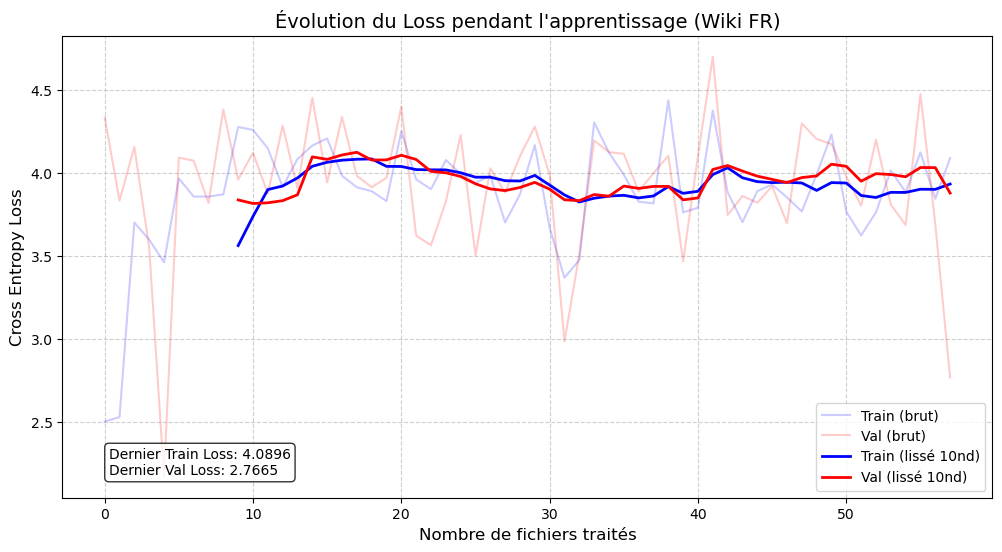

In [45]:
visualizer = gpt.TrainingVisualizer('history.json')
visualizer.plot_metrics(window_size=10) # Lissage sur 10 fichiers